# Defining Data Functions

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
## Imports

import sys
sys.path.append("..") # Adds the project root to the path

## Test Functions (before executing the defintions below)

In [3]:
from src.data_hazard import get_haz_dict

get_haz_dict()

/Users/arvedluetzen/.pyenv/versions/miniforge3-latest/envs/eth-fs2026-praktikum/lib/python3.12/site-packages/climada/hazard/io.py:696: UserWarning: Not all values are of type <class 'str'>. Casting values.
  warnings.warn(


{'WS': {'hazard': <climada.hazard.base.Hazard at 0x32218fc20>,
  'impf_set': <climada.entity.impact_funcs.impact_func_set.ImpactFuncSet at 0x32100f020>}}

In [4]:
from src.data_exposure import get_exposure

exposure = get_exposure(hazard_types=["WS"])

exposure.gdf

,DDEP_C_COD,DDEP_L_LIB,DREG_L_LIB,value,area,impf_WS,geometry
0,01,Ain,Auvergne-Rhône-Alpes,0.199,5762.4,1,"POLYGON ((6.16845 46.36746, 6.16668 46.37074, ..."
1,02,Aisne,Hauts-de-France,0.532,7361.7,1,"POLYGON ((4.25573 49.90398, 4.23694 49.90378, ..."
2,03,Allier,Auvergne-Rhône-Alpes,0.170,7340.1,1,"POLYGON ((4.00456 46.32748, 3.99436 46.32765, ..."
3,04,Alpes-de-Haute-Provence,Provence-Alpes-Côte d'Azur,0.025,6925.2,1,"POLYGON ((6.96709 44.62287, 6.9539 44.63783, 6..."
4,05,Hautes-Alpes,Provence-Alpes-Côte d'Azur,0.017,5548.7,1,"POLYGON ((7.07587 44.68512, 7.07424 44.69209, ..."
...,...,...,...,...,...,...,...
91,91,Essonne,Île-de-France,0.403,1804.4,1,"POLYGON ((2.58407 48.67715, 2.58038 48.68948, ..."
92,92,Hauts-de-Seine,Île-de-France,NaN,175.6,1,"POLYGON ((2.33598 48.93158, 2.33491 48.94154, ..."
93,93,Seine-Saint-Denis,Île-de-France,NaN,236.2,1,"POLYGON ((2.6026 48.92936, 2.6024 48.93532, 2...."
94,94,Val-de-Marne,Île-de-France,0.029,245.0,1,"POLYGON ((2.61482 48.76112, 2.60645 48.77333, ..."


In [5]:
from src.data_insurance import get_insurance

get_insurance(insurance_level=0.3, map_template=exposure)

TypeError: get_insurance() got an unexpected keyword argument 'map_template'

## get_hazard

In [ ]:
import numpy as np
from climada.util.api_client import Client
from climada.entity import ImpactFunc
from climada.entity.impact_funcs import ImpactFuncSet

def get_WS ():
    
    ## Get Hazard
    client = Client()
    ISO = "FRA"
    hazard = client.get_hazard(
        "storm_europe",
        properties={"country_iso3alpha": ISO}
    )
    
    ## Define Respective Impact Function
    impf_WS = ImpactFunc(
        id=1,
        name = "Storm Impact Function",
        intensity_unit="m/s",
        haz_type=hazard.haz_type,
        intensity=np.array([0, 12.1, 14.8, 16.8, 22]),
        mdd=np.array([0.0, 0.2, 0.4, 0.8, 1.0]),
        paa = np.ones(5)
    )
    
    impf_WS_set = ImpactFuncSet([impf_WS])
    
    return {
        "haz_type": hazard.haz_type, # Replace with Climada readable abbreviation
        "hazard": hazard, # Climada Hazard Object
        "impf_set": impf_WS_set # Impf already as set (to make later computations easier)
    }

In [ ]:
ws = get_WS()
ws

/Users/arvedluetzen/.pyenv/versions/miniforge3-latest/envs/eth-fs2026-praktikum/lib/python3.12/site-packages/climada/hazard/io.py:696: UserWarning: Not all values are of type <class 'str'>. Casting values.
  warnings.warn(


{'haz_type': 'WS',
 'hazard': <climada.hazard.base.Hazard at 0x31d93b560>,
 'impf_set': <climada.entity.impact_funcs.impact_func_set.ImpactFuncSet at 0x310d67da0>}

<GeoAxes: title={'center': 'Event ID 100: 100'}>

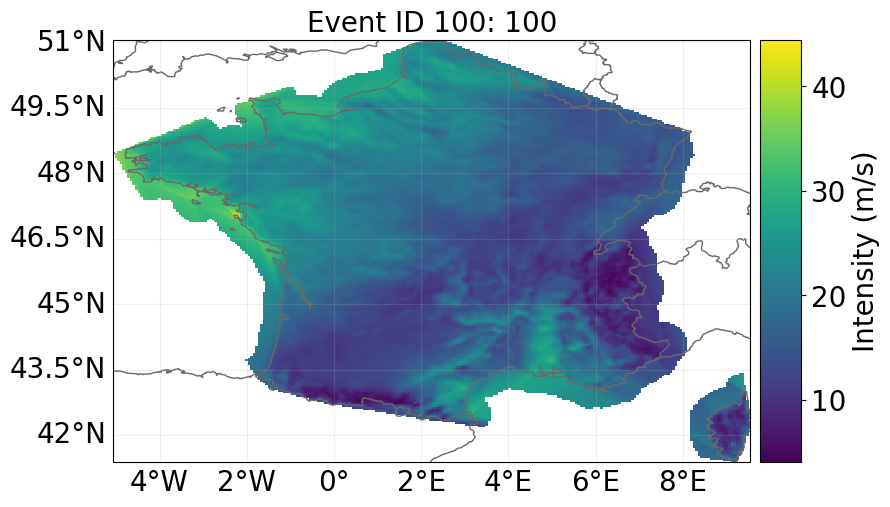

In [ ]:
## Check Hazard Object
ws["hazard"].plot_intensity(event=100)

<Axes: title={'center': 'WS 1: Storm Impact Function'}, xlabel='Intensity (m/s)', ylabel='Impact (%)'>

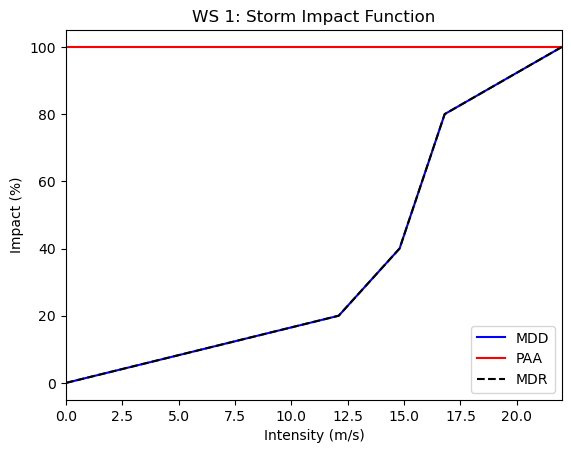

In [ ]:
## Check Impact function
ws["impf_set"].plot()

## get_haz_dict

In [ ]:
def get_haz_dict():
    """
    Function that uses different Hazard Functions
    to create a dictionary of hazards with:
    keys = haz_type
    values = dictionary with hazard and impact function
    """
    ## Add new get_hazard Functions as they come
    hazards = [
        get_WS()
    ]
    
    haz_dict = {}
    
    for hazard in hazards:
        haz_dict[hazard["haz_type"]] = {
            "hazard": hazard["hazard"],
            "impf_set": hazard["impf_set"]
        }
    
    return haz_dict

In [ ]:
haz_dict = get_haz_dict()

haz_dict

/Users/arvedluetzen/.pyenv/versions/miniforge3-latest/envs/eth-fs2026-praktikum/lib/python3.12/site-packages/climada/hazard/io.py:696: UserWarning: Not all values are of type <class 'str'>. Casting values.
  warnings.warn(


{'WS': {'hazard': <climada.hazard.base.Hazard at 0x324f20620>,
  'impf_set': <climada.entity.impact_funcs.impact_func_set.ImpactFuncSet at 0x31f20cf20>}}

<GeoAxes: title={'center': 'Event ID 100: 100'}>

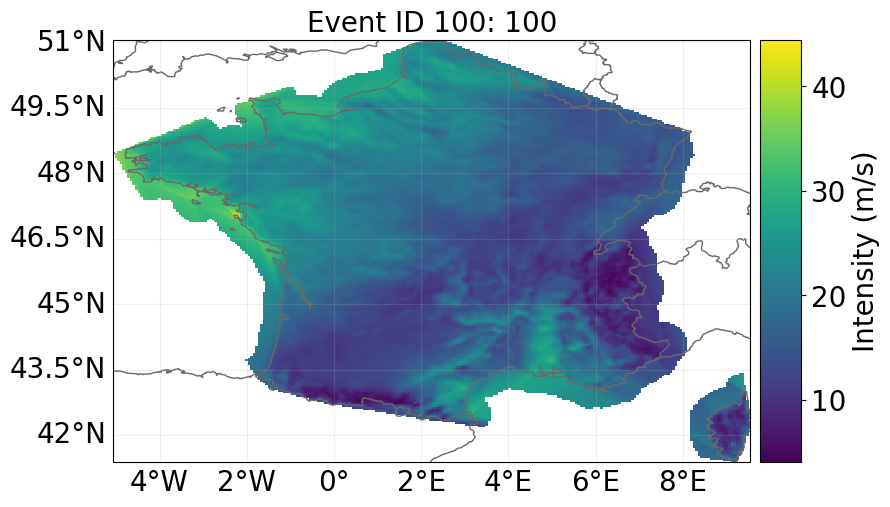

In [ ]:
haz_dict["WS"]["hazard"].plot_intensity(event=100)

## get_exposure

In [ ]:
exposure_gdf["value "]

0     19.9
1     53.2
2       17
3      2.5
4      1.7
      ... 
91    40.3
92       s
93       s
94     2.9
95    38.1
Name: value , Length: 96, dtype: object

In [ ]:
import json
import pandas as pd
import numpy as np
import geopandas as gpd
from climada.entity import Exposures
from shapely.geometry import shape
from src.config import DATA_PATH

hazard_types = ["WS", "FL"]
## Departement Boundaries
# import departement boundaries
boundaries_df = pd.read_csv(DATA_PATH + "geo-contours-departements.csv")
boundaries_df = boundaries_df.dropna(subset=["geometry"])
boundaries_df["geometry"] = boundaries_df["geometry"].apply(lambda x: shape(json.loads(x)))

boundaries_gdf = gpd.GeoDataFrame(boundaries_df, geometry="geometry")

## Crop Data per Departement
# import crop data per departement
crop_df = pd.read_excel(DATA_PATH +"crop_data_france.xlsx")

# Rename to obtain a key to merge
crop_df = crop_df.rename(columns={"number_department": "DDEP_C_COD"})

# Merge with Geometry + Data
exposure_gdf = boundaries_gdf.merge(crop_df.iloc[:, [0, 2, 3]], on="DDEP_C_COD")

## Process Data for CLIMADA
# Rename to obtain a key to merge
exposure_gdf["value"] = exposure_gdf["value"].replace("s", np.nan) # remove lines with value = "S" --> secret statistique mdr
exposure_gdf["value"] = exposure_gdf["value"] / 100

# add impact function column in exposure data
for hazard in hazard_types:
    exposure_gdf["impf_" + hazard] = 1

# create Exposure object out of dataframe
exposure_poly = Exposures(exposure_gdf) 

exposure_gdf

,geometry,DDEP_C_COD,DDEP_L_LIB,DREG_L_LIB,value,area,impf_WS,impf_FL
0,"POLYGON ((6.16845 46.36746, 6.16668 46.37074, ...",01,Ain,Auvergne-Rhône-Alpes,0.199,5762.4,1,1
1,"POLYGON ((4.25573 49.90398, 4.23694 49.90378, ...",02,Aisne,Hauts-de-France,0.532,7361.7,1,1
2,"POLYGON ((4.00456 46.32748, 3.99436 46.32765, ...",03,Allier,Auvergne-Rhône-Alpes,0.170,7340.1,1,1
3,"POLYGON ((6.96709 44.62287, 6.9539 44.63783, 6...",04,Alpes-de-Haute-Provence,Provence-Alpes-Côte d'Azur,0.025,6925.2,1,1
4,"POLYGON ((7.07587 44.68512, 7.07424 44.69209, ...",05,Hautes-Alpes,Provence-Alpes-Côte d'Azur,0.017,5548.7,1,1
...,...,...,...,...,...,...,...,...
91,"POLYGON ((2.58407 48.67715, 2.58038 48.68948, ...",91,Essonne,Île-de-France,0.403,1804.4,1,1
92,"POLYGON ((2.33598 48.93158, 2.33491 48.94154, ...",92,Hauts-de-Seine,Île-de-France,NaN,175.6,1,1
93,"POLYGON ((2.6026 48.92936, 2.6024 48.93532, 2....",93,Seine-Saint-Denis,Île-de-France,NaN,236.2,1,1
94,"POLYGON ((2.61482 48.76112, 2.60645 48.77333, ...",94,Val-de-Marne,Île-de-France,0.029,245.0,1,1


In [ ]:
import json
import pandas as pd
import numpy as np
import geopandas as gpd
from climada.entity import Exposures
from shapely.geometry import shape
from src.config import DATA_PATH

def get_exposure(hazard_types: list):
    """Returns Exposure Data in Climada Readable Polygons

    Args:
        hazard_types (list): List of 2 Letter Acronyms of Hazards
        (for impf_WS column)

    Returns:
        climada.entity.exposures.base.Exposures: exposure map
    """

    ## Departement Boundaries
    # import departement boundaries
    boundaries_df = pd.read_csv(DATA_PATH + "geo-contours-departements.csv")
    boundaries_df = boundaries_df.dropna(subset=["geometry"])
    boundaries_df["geometry"] = boundaries_df["geometry"].apply(lambda x: shape(json.loads(x)))

    boundaries_gdf = gpd.GeoDataFrame(boundaries_df, geometry="geometry")

    ## Crop Data per Departement
    # import crop data per departement
    crop_df = pd.read_excel(DATA_PATH +"crop_data_france.xlsx")

    # Rename to obtain a key to merge
    crop_df = crop_df.rename(columns={"number_department": "DDEP_C_COD"})

    # Merge with Geometry + Data
    exposure_gdf = boundaries_gdf.merge(crop_df.iloc[:, [0, 2, 3]], on="DDEP_C_COD")

    ## Process Data for CLIMADA
    # Rename to obtain a key to merge
    exposure_gdf["value"] = exposure_gdf["value"].replace("s", np.nan) # remove lines with value = "S" --> secret statistique mdr

    # add impact function column in exposure data
    for hazard in hazard_types:
        exposure_gdf["impf_" + hazard] = 1

    # create Exposure object out of dataframe
    exposure_poly = Exposures(exposure_gdf) 
    
    return exposure_poly

In [ ]:
get_exposure(["WS"]).gdf["area"]

0     5762.4
1     7361.7
2     7340.1
3     6925.2
4     5548.7
       ...  
91    1804.4
92     175.6
93     236.2
94     245.0
95    1245.9
Name: area, Length: 96, dtype: float64

## get_insurance

In [ ]:
from copy import deepcopy

insurance_level = 0.3
map_template = exposure_poly

map_gdf = deepcopy(map_template.gdf)

insurance_gdf = map_gdf.drop(columns=map_gdf.filter(regex="^impf_").columns)

insurance_gdf["value"] = insurance_level

insurance_gdf

,DDEP_C_COD,DDEP_L_LIB,DREG_L_LIB,value,area,geometry
0,01,Ain,Auvergne-Rhône-Alpes,0.3,5762.4,"POLYGON ((6.16845 46.36746, 6.16668 46.37074, ..."
1,02,Aisne,Hauts-de-France,0.3,7361.7,"POLYGON ((4.25573 49.90398, 4.23694 49.90378, ..."
2,03,Allier,Auvergne-Rhône-Alpes,0.3,7340.1,"POLYGON ((4.00456 46.32748, 3.99436 46.32765, ..."
3,04,Alpes-de-Haute-Provence,Provence-Alpes-Côte d'Azur,0.3,6925.2,"POLYGON ((6.96709 44.62287, 6.9539 44.63783, 6..."
4,05,Hautes-Alpes,Provence-Alpes-Côte d'Azur,0.3,5548.7,"POLYGON ((7.07587 44.68512, 7.07424 44.69209, ..."
...,...,...,...,...,...,...
91,91,Essonne,Île-de-France,0.3,1804.4,"POLYGON ((2.58407 48.67715, 2.58038 48.68948, ..."
92,92,Hauts-de-Seine,Île-de-France,0.3,175.6,"POLYGON ((2.33598 48.93158, 2.33491 48.94154, ..."
93,93,Seine-Saint-Denis,Île-de-France,0.3,236.2,"POLYGON ((2.6026 48.92936, 2.6024 48.93532, 2...."
94,94,Val-de-Marne,Île-de-France,0.3,245.0,"POLYGON ((2.61482 48.76112, 2.60645 48.77333, ..."


In [ ]:
def get_insurance(insurance_level: float, map_template):
    """_summary_

    Args:
        insurance_level (float): Value 0-1 of national insurance level
        map_template (Climada Polygon): exposure object

    Returns:
        GDF: with values for all departements
    """
    
    ## Make sure not to change the template
    insurance_gdf = deepcopy(map_template.gdf)

    ## Drop all impf Columns
    insurance_gdf = insurance_gdf.drop(columns=insurance_gdf.filter(regex="^impf_").columns)

    ## Set all Values Equal
    insurance_gdf["value"] = insurance_level
    
    return insurance_gdf

In [ ]:
get_insurance(0.3, exposure_poly)

,DDEP_C_COD,DDEP_L_LIB,DREG_L_LIB,value,area,geometry
0,01,Ain,Auvergne-Rhône-Alpes,0.3,5762.4,"POLYGON ((6.16845 46.36746, 6.16668 46.37074, ..."
1,02,Aisne,Hauts-de-France,0.3,7361.7,"POLYGON ((4.25573 49.90398, 4.23694 49.90378, ..."
2,03,Allier,Auvergne-Rhône-Alpes,0.3,7340.1,"POLYGON ((4.00456 46.32748, 3.99436 46.32765, ..."
3,04,Alpes-de-Haute-Provence,Provence-Alpes-Côte d'Azur,0.3,6925.2,"POLYGON ((6.96709 44.62287, 6.9539 44.63783, 6..."
4,05,Hautes-Alpes,Provence-Alpes-Côte d'Azur,0.3,5548.7,"POLYGON ((7.07587 44.68512, 7.07424 44.69209, ..."
...,...,...,...,...,...,...
91,91,Essonne,Île-de-France,0.3,1804.4,"POLYGON ((2.58407 48.67715, 2.58038 48.68948, ..."
92,92,Hauts-de-Seine,Île-de-France,0.3,175.6,"POLYGON ((2.33598 48.93158, 2.33491 48.94154, ..."
93,93,Seine-Saint-Denis,Île-de-France,0.3,236.2,"POLYGON ((2.6026 48.92936, 2.6024 48.93532, 2...."
94,94,Val-de-Marne,Île-de-France,0.3,245.0,"POLYGON ((2.61482 48.76112, 2.60645 48.77333, ..."
